# Capstone: AI/Automation Agents & Days to Close (DTC)

This notebook implements the three analysis techniques from the project plan:
1. **Comparative Cohort Analysis (A/B-style)**
2. **Time Series Analysis / Forecasting**
3. **Predictive Modeling (KNN, Logistic Regression, Decision Tree)**

It runs against the synthetic `sample_support_cases.csv` dataset. Once you export
real data from Zebra AI with the same column names, just update `DATA_PATH` below
— no other code changes are required.

In [1]:
# If running fresh, install dependencies:
# %pip install pandas numpy scikit-learn scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/sample_support_cases.csv"
# NOTE: keep_default_na=False prevents pandas from silently converting the
# literal string "None" (a valid agent_type value meaning "no agent") into NaN.
# Blank cells (e.g. handoff_time_hours for no-agent cases) are still treated as NaN.
df = pd.read_csv(DATA_PATH, parse_dates=["open_date", "close_date"], keep_default_na=False, na_values=[""])
df["has_agent"] = df["agent_type"] != "None"
print(df.shape)
df.head()

(1500, 27)


,case_id,open_date,close_date,days_to_close,severity,product_area,issue_type,complexity,effort_level,escalation_flag,reopen_flag,agent_type,lifecycle_stage_touched,handoff_time_hours,num_actions,automation_success,first_response_time_hours,resolution_accuracy,csat_score,sla_target_days,sla_met,repeat_contact_flag,kb_article_used,kb_coverage_score,engineer_workload,queue_depth,has_agent
0,CASE-100001,2024-01-14 04:00:00+00:00,2024-01-29 18:07:55.733000+00:00,15.59,Sev-C,Data Platform,Configuration,Medium,High,False,True,Knowledge,Creation,4.9,8,True,3.1,0.95,3.1,12,False,True,True,0.89,20,44,True
1,CASE-100002,2024-02-13 22:00:00+00:00,2024-03-05 08:21:57.654000+00:00,20.43,Sev-D,Identity,Performance,Medium,High,False,False,None,NaN,NaN,1,NaN,7.5,0.71,3.4,18,False,False,True,0.69,18,74,False
2,CASE-100003,2025-02-25 16:00:00+00:00,2025-03-13 14:52:15.732000+00:00,15.95,Sev-C,Networking,Bug,High,Low,False,False,Routing,Creation,4.3,8,True,5.0,0.97,3.6,12,False,False,False,0.37,9,38,True
3,CASE-100004,2024-11-10 21:00:00+00:00,2024-12-06 05:11:35.893000+00:00,25.34,Sev-D,Compute,Configuration,High,Medium,False,True,None,NaN,NaN,3,NaN,2.7,0.76,3.4,18,False,False,False,0.24,10,20,False
4,CASE-100005,2024-05-26 09:00:00+00:00,2024-06-08 13:18:34.748000+00:00,13.18,Sev-B,Networking,Feature Gap,High,Low,False,False,Routing,Creation,2.0,3,False,2.6,0.68,3.9,8,False,False,False,0.41,6,47,True


## 1. Comparative Cohort Analysis (A/B-style)

Compare DTC and quality metrics for agent-assisted vs. non-agent cases, segmented
by agent type and complexity. Uses Welch's t-test (unequal variances) to test
statistical significance of DTC differences between cohorts.

In [2]:
def summarize(frame: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "n": len(frame),
        "avg_dtc": frame["days_to_close"].mean(),
        "median_dtc": frame["days_to_close"].median(),
        "std_dtc": frame["days_to_close"].std(),
        "avg_csat": frame["csat_score"].mean(),
        "sla_met_rate": frame["sla_met"].mean(),
        "reopen_rate": frame["reopen_flag"].mean(),
    })

print("=== Overall: Agent-assisted vs. No-agent ===")
overall = df.groupby("has_agent").apply(summarize)
display(overall.round(2))

with_agent = df.loc[df["has_agent"], "days_to_close"]
no_agent = df.loc[~df["has_agent"], "days_to_close"]
t_stat, p_val = stats.ttest_ind(with_agent, no_agent, equal_var=False)
print(f"Welch t-test (With Agent vs No Agent) on DTC: t={t_stat:.3f}, p={p_val:.4g}, "
      f"mean_diff={with_agent.mean() - no_agent.mean():.2f}")

=== Overall: Agent-assisted vs. No-agent ===


,n,avg_dtc,median_dtc,std_dtc,avg_csat,sla_met_rate,reopen_rate
has_agent,,,,,,,
False,466.0,15.29,15.26,5.99,3.61,0.20,0.09
True,1034.0,12.57,12.27,6.05,4.11,0.42,0.06


Welch t-test (With Agent vs No Agent) on DTC: t=-8.117, p=1.557e-15, mean_diff=-2.72


=== By Agent Type ===


,n,avg_dtc,median_dtc,std_dtc,avg_csat,sla_met_rate,reopen_rate
agent_type,,,,,,,
Blended,228.0,9.72,9.07,5.59,4.13,0.67,0.05
Scoping,201.0,12.04,11.71,5.44,4.18,0.41,0.04
Knowledge,203.0,12.51,12.21,6.39,4.11,0.40,0.06
Routing,251.0,14.26,14.08,5.37,4.05,0.29,0.08
CaseHealth,151.0,14.85,15.10,6.29,4.11,0.28,0.08
None,466.0,15.29,15.26,5.99,3.61,0.20,0.09


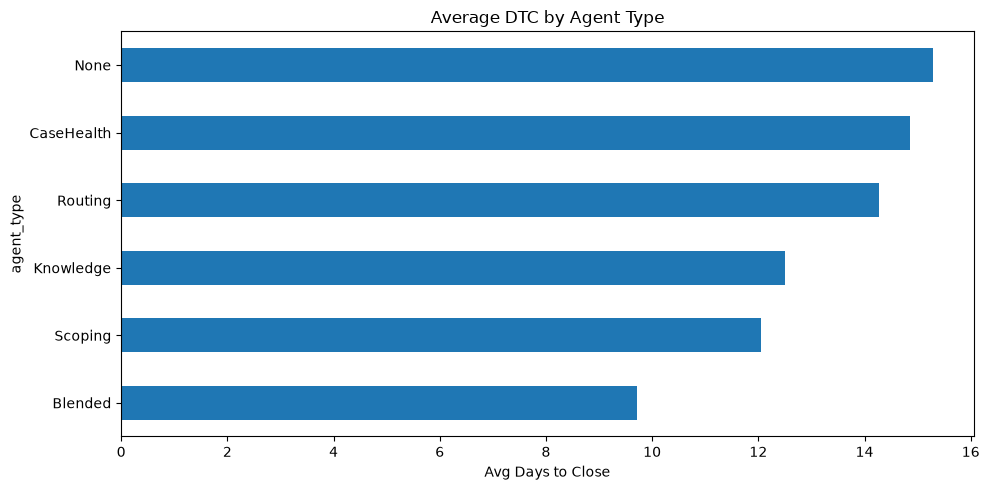

In [3]:
print("=== By Agent Type ===")
by_agent = df.groupby("agent_type").apply(summarize).sort_values("avg_dtc")
display(by_agent.round(2))

by_agent["avg_dtc"].sort_values().plot(kind="barh", title="Average DTC by Agent Type")
plt.xlabel("Avg Days to Close")
plt.tight_layout()
plt.show()

=== By Agent Type x Complexity (avg DTC) ===


complexity,Low,Medium,High
agent_type,,,
Blended,5.61,10.53,12.40
CaseHealth,10.80,14.44,19.63
Knowledge,9.00,11.62,19.36
None,11.14,15.60,20.72
Routing,11.31,14.30,19.25
Scoping,8.78,13.11,14.66


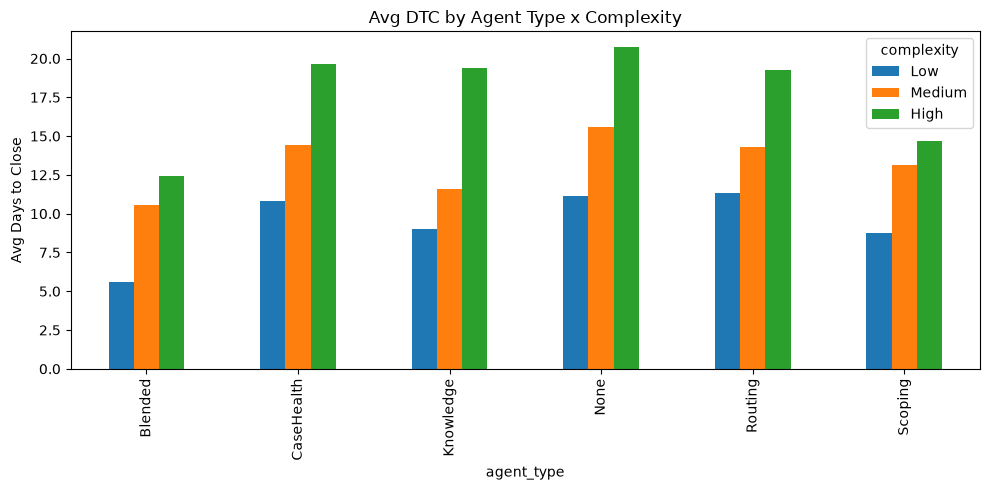

In [4]:
print("=== By Agent Type x Complexity (avg DTC) ===")
pivot = df.pivot_table(index="agent_type", columns="complexity", values="days_to_close", aggfunc="mean")
pivot = pivot[[c for c in ["Low", "Medium", "High"] if c in pivot.columns]]
display(pivot.round(2))

pivot.plot(kind="bar", title="Avg DTC by Agent Type x Complexity")
plt.ylabel("Avg Days to Close")
plt.tight_layout()
plt.show()

In [5]:
print("=== Specialized (Scoping) vs Generic (Routing) on High-complexity cases ===")
scoping_high = df[(df["agent_type"] == "Scoping") & (df["complexity"] == "High")]["days_to_close"]
routing_high = df[(df["agent_type"] == "Routing") & (df["complexity"] == "High")]["days_to_close"]
t_stat, p_val = stats.ttest_ind(scoping_high, routing_high, equal_var=False)
print(f"Scoping avg DTC: {scoping_high.mean():.2f} (n={len(scoping_high)})")
print(f"Routing avg DTC: {routing_high.mean():.2f} (n={len(routing_high)})")
print(f"Welch t-test: t={t_stat:.3f}, p={p_val:.4g}")

=== Specialized (Scoping) vs Generic (Routing) on High-complexity cases ===
Scoping avg DTC: 14.66 (n=46)
Routing avg DTC: 19.25 (n=53)
Welch t-test: t=-4.510, p=2.173e-05


In [6]:
print("=== Blended vs Best Single Agent per Severity ===")
rows = []
single_agents = [a for a in df["agent_type"].unique() if a not in ("None", "Blended")]
for sev in sorted(df["severity"].unique()):
    blended_avg = df[(df["severity"] == sev) & (df["agent_type"] == "Blended")]["days_to_close"].mean()
    single_avgs = {
        a: df[(df["severity"] == sev) & (df["agent_type"] == a)]["days_to_close"].mean()
        for a in single_agents
    }
    best_agent = min(single_avgs, key=single_avgs.get)
    rows.append({
        "severity": sev,
        "blended_avg_dtc": round(blended_avg, 2),
        "best_single_agent": best_agent,
        "best_single_avg_dtc": round(single_avgs[best_agent], 2),
    })
display(pd.DataFrame(rows))

=== Blended vs Best Single Agent per Severity ===


,severity,blended_avg_dtc,best_single_agent,best_single_avg_dtc
0,Sev-A,4.73,Knowledge,6.75
1,Sev-B,6.79,Knowledge,8.87
2,Sev-C,10.39,Scoping,12.62
3,Sev-D,15.79,Scoping,17.67


## 2. Time Series Analysis / Forecasting

Aggregate DTC by close month, compute a rolling average, fit a linear trend to
detect drift, and compare a before/after split around a rollout cutoff date.

,n_cases,avg_dtc,avg_dtc_no_agent,avg_dtc_with_agent,rolling_avg_3mo
close_date,,,,,
2024-01-01 00:00:00+00:00,54,10.97,12.39,10.53,10.97
2024-02-01 00:00:00+00:00,80,13.09,14.30,12.69,12.03
2024-03-01 00:00:00+00:00,75,11.85,12.52,11.48,11.97
2024-04-01 00:00:00+00:00,86,13.25,16.60,11.95,12.73
2024-05-01 00:00:00+00:00,97,13.82,14.60,13.31,12.97
2024-06-01 00:00:00+00:00,80,13.54,14.19,13.28,13.53
2024-07-01 00:00:00+00:00,92,13.77,16.01,13.03,13.71
2024-08-01 00:00:00+00:00,94,12.32,13.83,11.47,13.21
2024-09-01 00:00:00+00:00,104,13.65,17.26,11.66,13.25


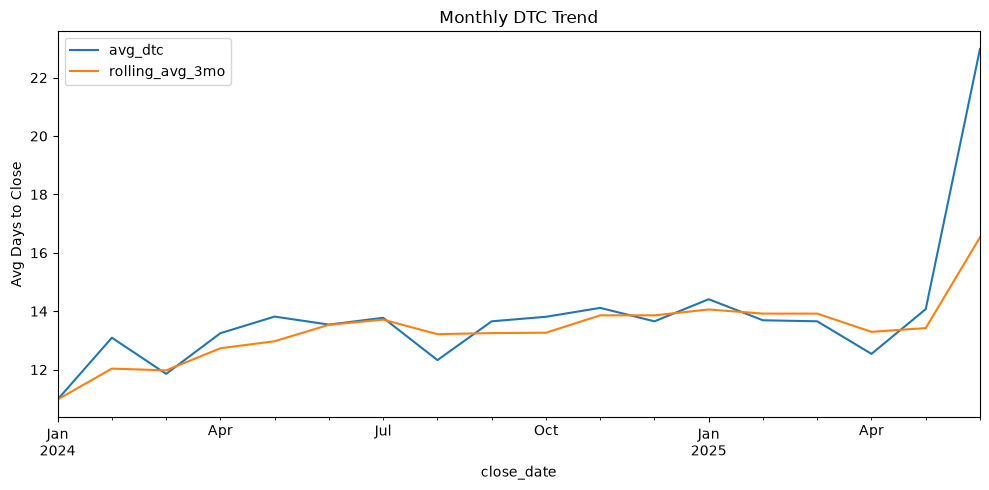

In [7]:
monthly = df.set_index("close_date").resample("MS").agg(
    n_cases=("days_to_close", "size"),
    avg_dtc=("days_to_close", "mean"),
)
monthly["avg_dtc_no_agent"] = df[~df["has_agent"]].set_index("close_date").resample("MS")["days_to_close"].mean()
monthly["avg_dtc_with_agent"] = df[df["has_agent"]].set_index("close_date").resample("MS")["days_to_close"].mean()
monthly["rolling_avg_3mo"] = monthly["avg_dtc"].rolling(3, min_periods=1).mean()
display(monthly.round(2))

monthly[["avg_dtc", "rolling_avg_3mo"]].plot(title="Monthly DTC Trend")
plt.ylabel("Avg Days to Close")
plt.tight_layout()
plt.show()

In [8]:
# Linear trend: month index vs avg_dtc
x = np.arange(len(monthly))
y = monthly["avg_dtc"].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
direction = "IMPROVING (DTC trending down)" if slope < 0 else "WORSENING (DTC trending up)"
print(f"Slope (days/month): {slope:.4f} -> {direction}")
print(f"Intercept: {intercept:.2f}")
print(f"R^2: {r_value**2:.4f}, p-value: {p_value:.4g}")

# Before/after split at the midpoint month as a stand-in "agent rollout" date.
# Replace with the actual rollout date once real production data is loaded.
cutoff = monthly.index[len(monthly) // 2]
before = df[df["close_date"] < cutoff]["days_to_close"]
after = df[df["close_date"] >= cutoff]["days_to_close"]
print(f"\nBefore {cutoff.date()}: avg DTC = {before.mean():.2f} (n={len(before)})")
print(f"After  {cutoff.date()}: avg DTC = {after.mean():.2f} (n={len(after)})")

Slope (days/month): 0.2499 -> WORSENING (DTC trending up)
Intercept: 11.72
R^2: 0.2984, p-value: 0.01901

Before 2024-10-01: avg DTC = 13.04 (n=762)
After  2024-10-01: avg DTC = 13.80 (n=738)


## 3. Predictive Modeling (Classification)

Predict which agent-assisted cases achieve **>=25% DTC reduction** vs. a
same-severity/complexity/effort no-agent baseline ("high DTC-reduction
potential"). Train KNN, Logistic Regression, and a Decision Tree, then rank
feature importance to identify which case attributes predict the greatest
value from agent intervention.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

no_agent_df = df[~df["has_agent"]]

def baseline_dtc(row):
    peers = no_agent_df[
        (no_agent_df["severity"] == row["severity"]) &
        (no_agent_df["complexity"] == row["complexity"]) &
        (no_agent_df["effort_level"] == row["effort_level"])
    ]
    return peers["days_to_close"].median() if len(peers) else np.nan

agent_df = df[df["has_agent"]].copy()
agent_df["baseline_dtc"] = agent_df.apply(baseline_dtc, axis=1)
agent_df = agent_df.dropna(subset=["baseline_dtc"])
agent_df["improvement_pct"] = (agent_df["baseline_dtc"] - agent_df["days_to_close"]) / agent_df["baseline_dtc"]
agent_df["label"] = (agent_df["improvement_pct"] >= 0.25).astype(int)

print(f"Labeled {len(agent_df)} agent-assisted cases.")
print(f"Positive class (>=25% DTC improvement): {agent_df['label'].sum()}")

numeric_features = ["engineer_workload", "queue_depth", "kb_coverage_score"]
ordinal_maps = {
    "severity": {"Sev-A": 0, "Sev-B": 1, "Sev-C": 2, "Sev-D": 3},
    "complexity": {"Low": 0, "Medium": 1, "High": 2},
    "effort_level": {"Low": 0, "Medium": 1, "High": 2},
}
for col, mapping in ordinal_maps.items():
    agent_df[f"{col}_enc"] = agent_df[col].map(mapping)

categorical_features = ["product_area", "issue_type"]
feature_cols = numeric_features + [f"{c}_enc" for c in ordinal_maps] + categorical_features

X = agent_df[feature_cols]
y = agent_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7, stratify=y)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
], remainder="passthrough")

Labeled 1034 agent-assisted cases.
Positive class (>=25% DTC improvement): 397


In [10]:
def evaluate(name, pipeline):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    acc = accuracy_score(y_test, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average="binary", zero_division=0)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}\n")
    return pipeline

knn_pipe = Pipeline([("prep", preprocess), ("model", KNeighborsClassifier(n_neighbors=5))])
evaluate("KNN (k=5)", knn_pipe)

logreg_pipe = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=1000))])
evaluate("Logistic Regression", logreg_pipe)

tree_pipe = Pipeline([("prep", preprocess), ("model", DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=7))])
tree_pipe = evaluate("Decision Tree (CART)", tree_pipe)

=== KNN (k=5) ===
Accuracy: 0.529 | Precision: 0.351 | Recall: 0.273 | F1: 0.307

=== Logistic Regression ===
Accuracy: 0.622 | Precision: 0.508 | Recall: 0.333 | F1: 0.402

=== Decision Tree (CART) ===
Accuracy: 0.595 | Precision: 0.462 | Recall: 0.364 | F1: 0.407



=== Top Predictive Features (Decision Tree) ===


severity_enc                  0.2975
kb_coverage_score             0.2420
effort_level_enc              0.2003
queue_depth                   0.1159
engineer_workload             0.0670
product_area_Storage          0.0254
issue_type_Outage             0.0180
product_area_Collaboration    0.0164
issue_type_How-To             0.0111
product_area_Networking       0.0063
dtype: float64

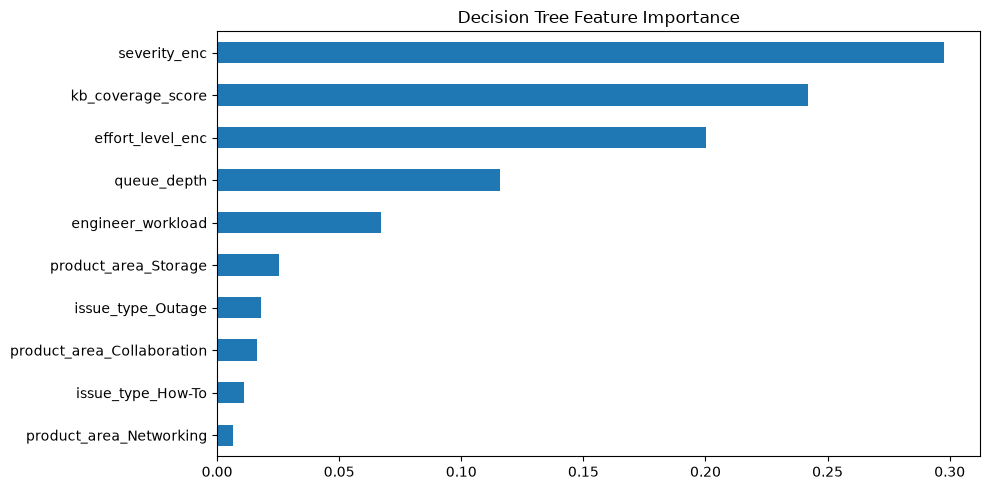

In [11]:
# Feature importance from the Decision Tree
encoded_cat_names = tree_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_features)
passthrough_names = numeric_features + [f"{c}_enc" for c in ordinal_maps]
all_feature_names = list(encoded_cat_names) + passthrough_names

importances = pd.Series(
    tree_pipe.named_steps["model"].feature_importances_, index=all_feature_names
).sort_values(ascending=False)

print("=== Top Predictive Features (Decision Tree) ===")
display(importances.head(10).round(4))

importances.head(10).sort_values().plot(kind="barh", title="Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

## Next Steps
- Replace `DATA_PATH` with the real Zebra AI / CRM export once available — the
  pipeline is schema-compatible and requires no other changes.
- Port the feature pipeline to Azure ML for scaled training/deployment, per
  the project plan.
- Translate model outputs (feature importance, cohort deltas) into the
  stakeholder-facing playbook, e.g. "Deploy the Scoping agent on Severity-B,
  High-complexity cases in Product Area X to reduce average DTC by N days."